# EDA 6.003: Post-Normalization EDA


## Imports and data load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from steam_review_ml.data.preprocess import (
    filter_reviews,
    load_raw_reviews,
    select_features,
)


def add_review_word_count(temp):
    temp["review_word_count"] = temp["review"].fillna("").apply(lambda x: len(str(x).split()))
    return temp


RAW_PATH = Path("../../data/raw/steam_reviews_full.csv")
df_raw = load_raw_reviews(RAW_PATH, nrows=1_000_000)
df_clean = filter_reviews(df_raw)
df = select_features(df_clean)
df = add_review_word_count(df)
print("Shape:", df.shape)

Shape: (373283, 24)


In [2]:
df.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'review',
       'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'votes_funny', 'comment_count',
       'steam_purchase', 'received_for_free', 'written_during_early_access',
       'timestamp_created', 'timestamp_updated', 'author.last_played',
       'is_helpful', 'review_length_chars',
       'author_playtime_last_two_weeks_missing',
       'author_playtime_at_review_missing', 'review_word_count'],
      dtype='str')

## Column definitions

In [3]:
CAP_THEN_LOG_COLS = ["votes_helpful", "author.playtime_last_two_weeks"]
LOG_ONLY_COLS = ["votes_funny", "author.playtime_at_review", "author.num_games_owned", "author.num_reviews", "review_word_count"]
NORM_COLS = CAP_THEN_LOG_COLS + LOG_ONLY_COLS

## Original (kept as reference)

In [4]:
df_original_raw = df[NORM_COLS].copy()
df_original_raw.describe()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,3.732830e+05,3.732830e+05,373283.000000,373283.000000,373283.000000
mean,1.460618,76.230217,2.301261e+04,7.555060e+03,160.590539,13.668822,30.023958
std,28.806445,540.969950,9.941574e+06,2.823334e+04,309.123388,40.472369,77.421366
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000e+00,5.520000e+02,33.000000,2.000000,3.000000
50%,0.000000,0.000000,0.000000e+00,1.708000e+03,82.000000,5.000000,9.000000
75%,1.000000,0.000000,0.000000e+00,5.890000e+03,180.000000,13.000000,25.000000
max,7352.000000,20924.000000,4.294967e+09,3.062784e+06,20969.000000,5236.000000,2667.000000


## Normalization Through TensorFlow

In [5]:
import tensorflow as tf

CAP_P = 0.99
caps = {col: df[col].quantile(CAP_P) for col in CAP_THEN_LOG_COLS}
print("Caps:", caps)

2026-03-13 06:12:24.941776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 06:12:24.946607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773396744.952277   34015 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773396744.954227   34015 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773396744.958655   34015 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Caps: {'votes_helpful': np.float64(14.0), 'author.playtime_last_two_weeks': np.float64(1971.0)}


In [6]:
# Normalize only the numeric NORM_COLS with TensorFlow,
# then merge them back into the full DataFrame.

class SteamNormalizer(tf.keras.layers.Layer):
    def __init__(self, caps, cap_then_log_cols, log_only_cols, **kwargs):
        super().__init__(**kwargs)
        self.caps = caps
        self.cap_then_log_cols = cap_then_log_cols
        self.log_only_cols = log_only_cols

    def call(self, inputs):
        x = {k: tf.convert_to_tensor(v) for k, v in inputs.items()}
        for col in self.cap_then_log_cols:
            c = tf.cast(self.caps[col], x[col].dtype)
            x[col] = tf.math.log1p(tf.minimum(x[col], c))
        for col in self.log_only_cols:
            x[col] = tf.math.log1p(x[col])
        return x

norm_layer = SteamNormalizer(
    caps=caps,
    cap_then_log_cols=CAP_THEN_LOG_COLS,
    log_only_cols=LOG_ONLY_COLS,
)

# Build a batch only for the numeric columns we want to normalize
batch = {
    col: tf.constant(df[col].to_numpy().reshape(-1, 1), dtype=tf.float32)
    for col in NORM_COLS
}

normed = norm_layer(batch)

# Start from the original df and overwrite the normalized columns
df_tf = df.copy()
for col in NORM_COLS:
    df_tf[col] = normed[col].numpy().reshape(-1)

df_tf.describe()

I0000 00:00:1773396747.116009   34015 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0


,review_id,app_id,author.steamid,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,author.playtime_at_review,votes_funny,comment_count,timestamp_created,timestamp_updated,author.last_played,review_length_chars,review_word_count
count,3.732830e+05,373283.000000,3.732830e+05,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,3.732830e+05,3.732830e+05,3.732830e+05,373283.000000,373283.000000
mean,4.723104e+07,115500.257740,7.656120e+16,0.256175,4.337872,2.000362,0.575543,7.448884,0.092224,0.127180,1.525637e+09,1.529604e+09,1.559878e+09,164.976841,2.478302
std,2.486733e+07,142099.819703,3.071860e+08,0.509201,1.267242,1.030242,1.700467,1.752870,0.380626,1.701312,7.750251e+07,7.556558e+07,1.089393e+08,436.149524,1.241614
min,4.300000e+01,70.000000,7.656120e+16,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,1.290320e+09,1.290320e+09,0.000000e+00,4.000000,0.693147
25%,2.585480e+07,620.000000,7.656120e+16,0.000000,3.526361,1.098612,0.000000,6.315358,0.000000,0.000000,1.475591e+09,1.480004e+09,1.547265e+09,18.000000,1.386294
50%,5.066274e+07,4000.000000,7.656120e+16,0.000000,4.418840,1.791759,0.000000,7.443664,0.000000,0.000000,1.557956e+09,1.561848e+09,1.589344e+09,48.000000,2.302585
75%,7.017217e+07,292030.000000,7.656120e+16,0.693147,5.198497,2.639057,0.000000,8.681181,0.000000,0.000000,1.591062e+09,1.593125e+09,1.606379e+09,136.000000,3.258096
max,8.521823e+07,292030.000000,7.656120e+16,2.708050,9.950849,8.563504,7.586803,14.934835,22.180710,420.000000,1.611425e+09,1.611425e+09,1.611429e+09,8000.000000,7.889084


In [9]:
df_tf.head(5)

,review_id,app_id,app_name,author.steamid,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,...,received_for_free,written_during_early_access,timestamp_created,timestamp_updated,author.last_played,is_helpful,review_length_chars,author_playtime_last_two_weeks_missing,author_playtime_at_review_missing,review_word_count
3,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,"One of the best RPG's of all time, worthy of a...",True,0.0,1.791759,1.386294,7.586803,...,False,False,1611379970,1611379970,1.611384e+09,False,59,False,False,2.564949
5,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,"good story, good graphics. lots to do.",True,0.0,2.484907,0.693147,6.714170,...,False,False,1611379264,1611379264,1.611379e+09,False,38,False,False,2.079442
6,85184064,292030,The Witcher 3: Wild Hunt,76561198119302812,"dis gud,",True,0.0,3.332205,1.098612,7.586803,...,False,False,1611379091,1611379091,1.611352e+09,False,8,False,False,1.098612
18,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,favorite game of all time cant wait for the Ne...,True,0.0,3.526361,0.693147,5.181784,...,False,False,1611373086,1611373086,1.611219e+09,False,59,False,False,2.484907
20,85179753,292030,The Witcher 3: Wild Hunt,76561198996835044,Why wouldn't you get this,True,0.0,4.882802,1.098612,7.586803,...,False,False,1611371978,1611371978,1.611371e+09,False,25,False,False,1.791759


## Feature vs target (from eda_004)

Quick check that the **normalized** features still show reasonable signal vs the two main targets:

- `recommended` (classification)
- `votes_helpful` (regression target / helpfulness signal)

We use the TensorFlow-normalized dataframe `df_tf` here so this section reflects what the models will see.

/tmp/ipykernel_34015/1390518305.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(
/tmp/ipykernel_34015/1390518305.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(
/tmp/ipykernel_34015/1390518305.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(
/tmp/ipykernel_34015/1390518305.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(
/tmp/ipykernel_34015/1390518305.py:14: MatplotlibDeprecationWarning: The 'labels' parameter 

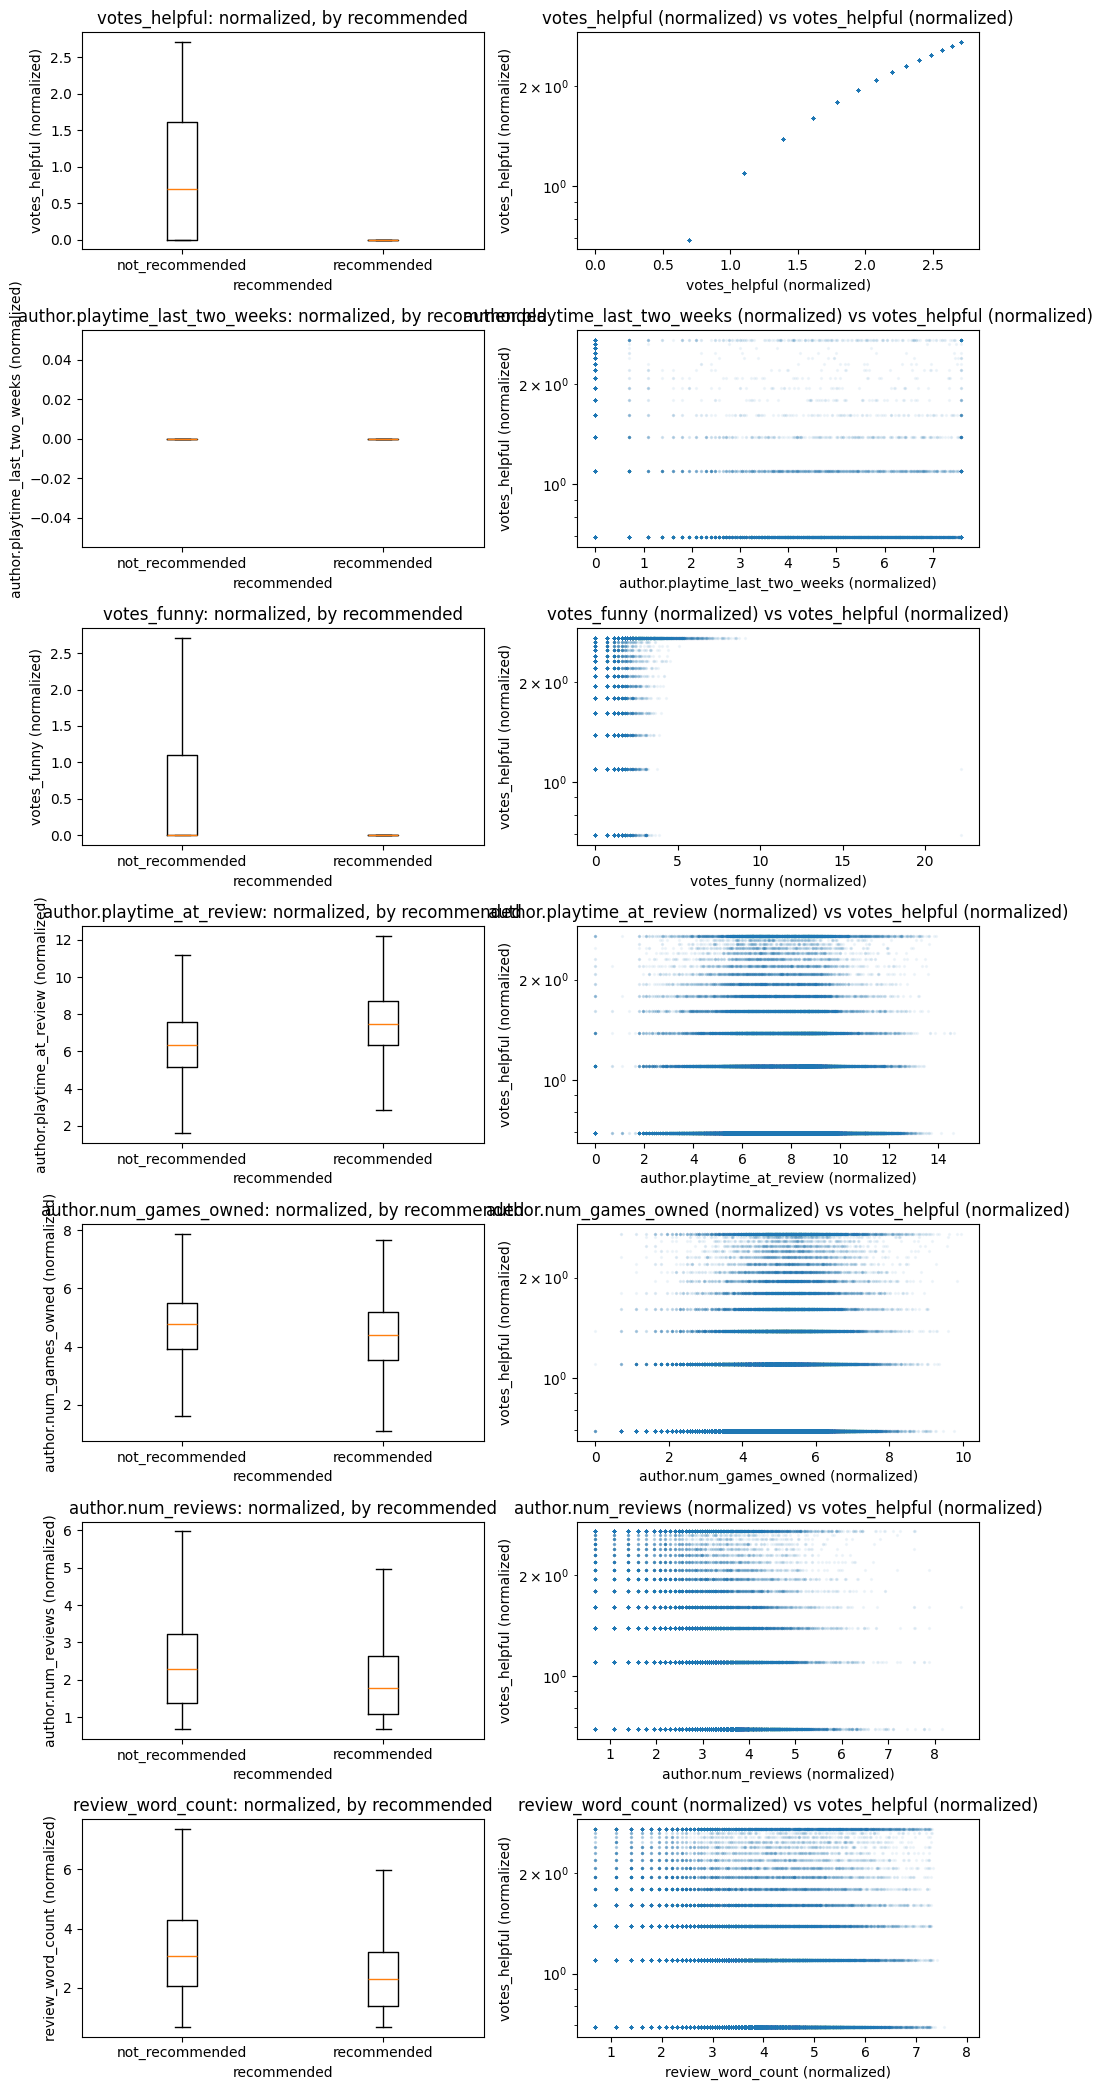

In [11]:
# Feature vs target: normalized features vs recommended and votes_helpful

# All columns and targets are taken from df_tf (post-normalization features).

fig, axes = plt.subplots(len(NORM_COLS), 2, figsize=(10, 3 * len(NORM_COLS)))
if len(NORM_COLS) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(NORM_COLS):
    # Left: distribution by recommended within normalized features
    ax_left = axes[i, 0]
    data_not_rec = df_tf.loc[df_tf["recommended"] == False, col].dropna()
    data_rec = df_tf.loc[df_tf["recommended"] == True, col].dropna()
    ax_left.boxplot(
        [data_not_rec, data_rec],
        labels=["not_recommended", "recommended"],
        showfliers=False,
    )
    ax_left.set_title(f"{col}: normalized, by recommended")
    ax_left.set_xlabel("recommended")
    ax_left.set_ylabel(f"{col} (normalized)")

    # Right: scatter vs votes_helpful (normalized)
    ax_right = axes[i, 1]
    ax_right.scatter(
        df_tf[col].values,
        df_tf["votes_helpful"].values,
        alpha=0.05,
        s=2,
    )
    ax_right.set_xlabel(f"{col} (normalized)")
    ax_right.set_ylabel("votes_helpful (normalized)")
    ax_right.set_title(f"{col} (normalized) vs votes_helpful (normalized)")
    ax_right.set_yscale("log")

plt.tight_layout()
plt.show()

# Correlation heatmap on normalized numeric features


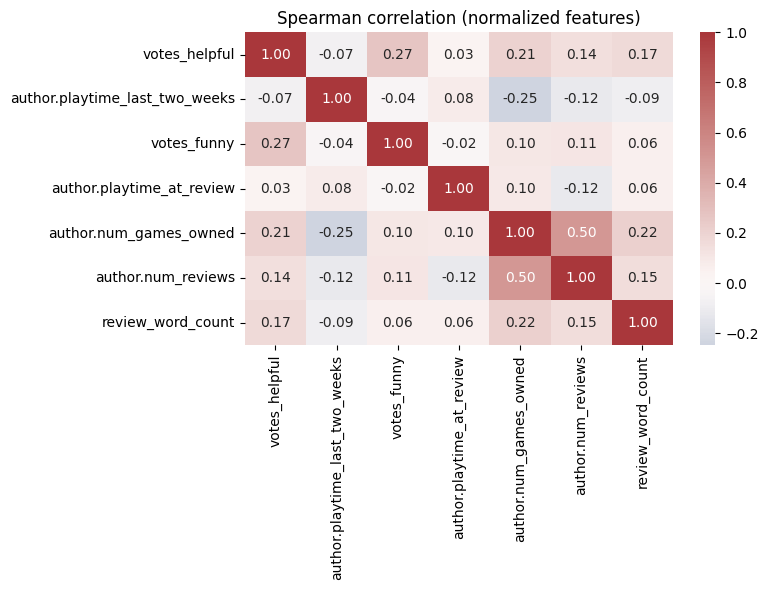

In [ ]:
num_df = df_tf[NORM_COLS].copy()

corr = num_df.corr(method="spearman")

try:
    import seaborn as sns  # type: ignore
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Spearman correlation (normalized features)")
    plt.tight_layout()
    plt.show()
except Exception:
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(NORM_COLS)), NORM_COLS, rotation=90)
    plt.yticks(range(len(NORM_COLS)), NORM_COLS)
    plt.title("Spearman correlation (normalized features)")
    plt.tight_layout()
    plt.show()

# Simple z-score outlier check on normalized features


In [ ]:

outlier_stats = []
for col in NORM_COLS:
    s = df_tf[col].dropna()
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        frac = 0.0
    else:
        z = (s - mean).abs() / std
        frac = (z > 3.0).mean()
    outlier_stats.append((col, frac))

print("Fraction of z-score>3 outliers per column (normalized):")
for col, frac in outlier_stats:
    print(f"  {col}: {frac:.6f}")

Fraction of z-score>3 outliers per column (normalized):
  votes_helpful: 0.025528
  author.playtime_last_two_weeks: 0.044982
  votes_funny: 0.017284
  author.playtime_at_review: 0.007000
  author.num_games_owned: 0.001431
  author.num_reviews: 0.006100
  review_word_count: 0.005385


### Target transform for helpfulness regression

If we train a **regression model on `votes_helpful`**, we may want to use a log-transformed target, e.g. `log1p(votes_helpful)`, to reduce extreme skew.

This does **not** change the normalized feature set; it is only a choice about the target. The current plan is:

- keep `votes_helpful` as-is for classification-style labels (e.g. `is_helpful`),
- and consider `log1p(votes_helpful)` as the target for linear regression baselines (documenting the choice alongside the feature transforms when we implement those models).

# Simple LinearRegression for Homoskedasticity

In [20]:
from sklearn.linear_model import LinearRegression

# Use normalized features for a very simple linear baseline
X = df_tf[NORM_COLS].fillna(0.0).to_numpy()

# --- Model 1: raw votes_helpful ---
y_raw = df["votes_helpful"].to_numpy().astype(float)
lin_raw = LinearRegression()
lin_raw.fit(X, y_raw)
yhat_raw = lin_raw.predict(X)
resid_raw = y_raw - yhat_raw

# --- Model 2: log1p(votes_helpful) ---
y_log = np.log1p(y_raw)
lin_log = LinearRegression()
lin_log.fit(X, y_log)
yhat_log = lin_log.predict(X)
# Back-transform predictions to raw scale for residuals
yhat_log_raw = np.expm1(yhat_log)
resid_log_raw = y_raw - yhat_log_raw


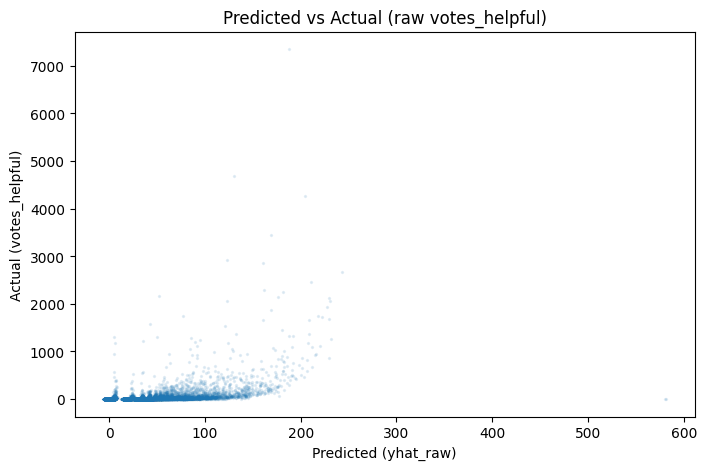

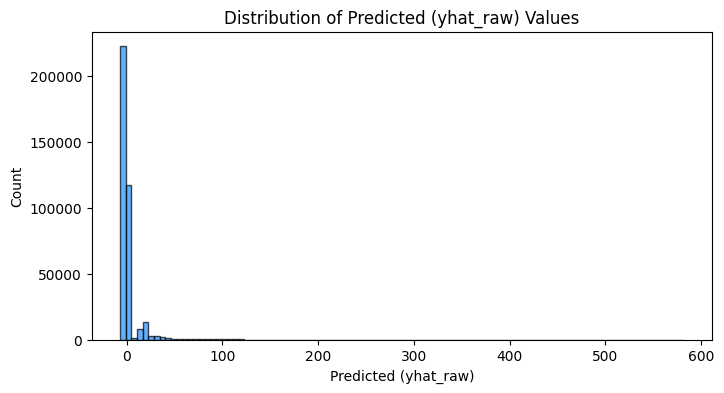

In [28]:
# Plot histogram and scatter of raw predictions

import matplotlib.pyplot as plt

# Scatter plot: predicted vs actual (raw votes_helpful)
plt.figure(figsize=(8, 5))
plt.scatter(yhat_raw, y_raw, alpha=0.1, s=2)
plt.xlabel("Predicted (yhat_raw)")
plt.ylabel("Actual (votes_helpful)")
plt.title("Predicted vs Actual (raw votes_helpful)")
plt.show()

# Optionally, histogram of predicted values
plt.figure(figsize=(8, 4))
plt.hist(yhat_raw, bins=100, alpha=0.7, color="dodgerblue", edgecolor="k")
plt.xlabel("Predicted (yhat_raw)")
plt.ylabel("Count")
plt.title("Distribution of Predicted (yhat_raw) Values")
plt.show()

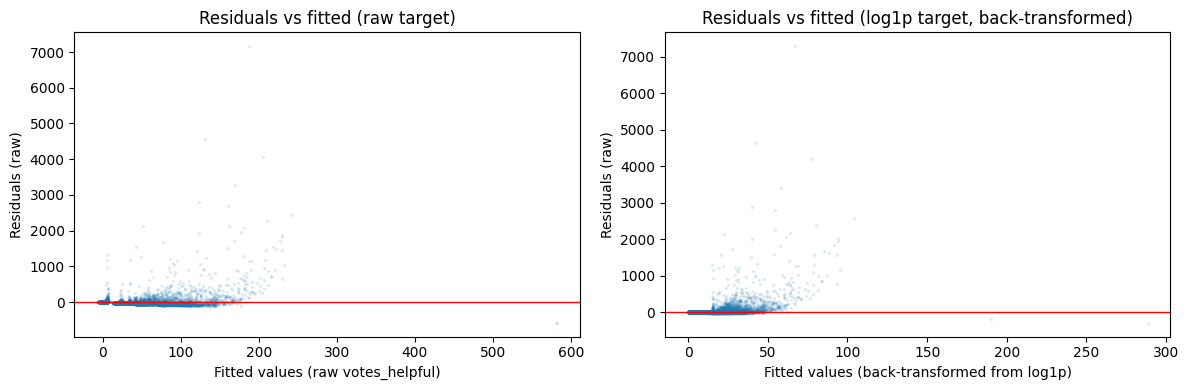

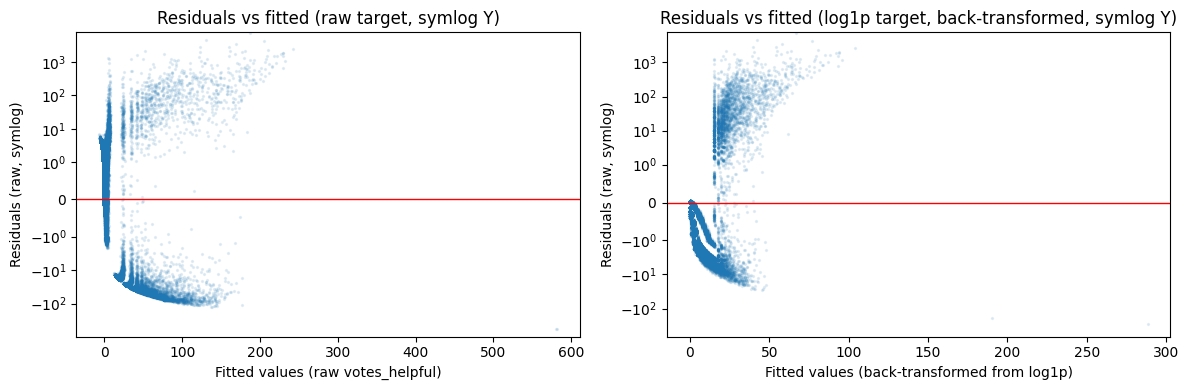

In [27]:
# moved to eda_006_normalization_004.ipynb


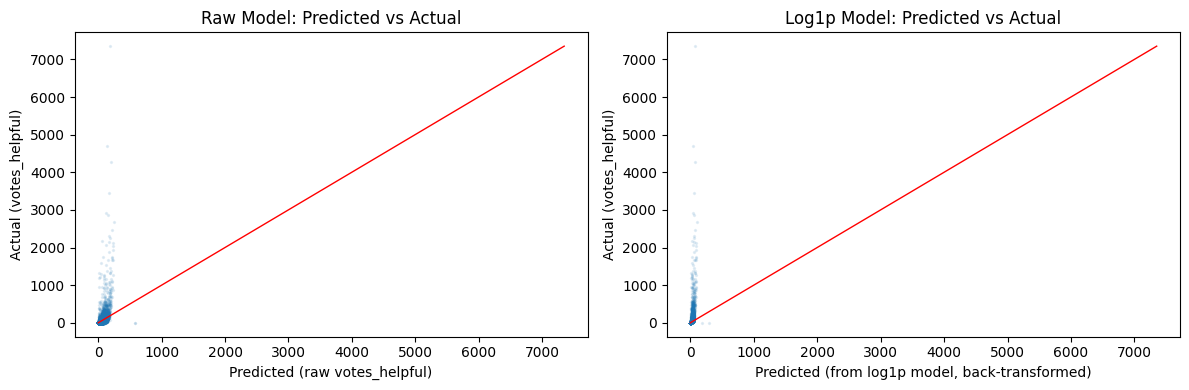

In [23]:
# Plot predicted vs actual (normal scatter plot) for both models

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw model: predicted vs actual
axes[0].scatter(yhat_raw, y_raw, alpha=0.1, s=2)
axes[0].plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], color="red", linewidth=1)
axes[0].set_xlabel("Predicted (raw votes_helpful)")
axes[0].set_ylabel("Actual (votes_helpful)")
axes[0].set_title("Raw Model: Predicted vs Actual")

# Log1p model: predicted (back-transformed) vs actual
axes[1].scatter(yhat_log_raw, y_raw, alpha=0.1, s=2)
axes[1].plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], color="red", linewidth=1)
axes[1].set_xlabel("Predicted (from log1p model, back-transformed)")
axes[1].set_ylabel("Actual (votes_helpful)")
axes[1].set_title("Log1p Model: Predicted vs Actual")

plt.tight_layout()
plt.show()

# Short explanation:
# This compares predicted vs actual votes_helpful for both baseline (raw) and log1p regression models,
# helping visualize prediction quality by how closely points follow the identity (y=x) line.